**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 19/06/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.feature_engineering.ChemicalFeatureEngineering import ChemicalFeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.bags_compositions import ALL_SAMPLES
from config.elements_coefficients import RESISTIVITY_FACTORS, ENRICHMENT_FACTORS
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()
chfe = ChemicalFeatureEngineering(
    all_samples=ALL_SAMPLES,
    resistivity_factors=RESISTIVITY_FACTORS,
    enrichment_factors=ENRICHMENT_FACTORS,
)



## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
ANNEALING_SCHEMA_DATE = "240826"
SN_SCHEMA_DATE = "190826"

VARIABLE = "iacs"
PROCESS = f"annealing_{VARIABLE}"
TAG = f"model_{PROCESS}_{ANNEALING_SCHEMA_DATE}_all-data"

# ---- Paths ----
FILE_NAME = f"dataset_{PROCESS}.csv"
FILE_NAME_SCHEMA_DATA = f"schema_annealing_essays_{ANNEALING_SCHEMA_DATE}.csv"
FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"
FILE_NAME_SN_COMPOSITION = f"serial-number-encoding_{SN_SCHEMA_DATE}.csv"


# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["initial_diameter", "IRI", "purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 1200

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.0 Chemical data

In [96]:
FEATURES_TO_SELECT = [
    "experiment_id",
    "material_reference",
    "purity",
    "initial_diameter",
    "temperature",
    "time",
    "iacs",
    "tensile_strength",
    "elongation",
    "iacs_final",
    "tensile_strength_final",
    "elongation_final",
]

In [ ]:
df_sn = pd.read_csv(os.path.join(varv.PATHS.data_structured, FILE_NAME_SN_COMPOSITION))
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
df_nnan = df_raw.dropna(how="all")
df_feat = df_nnan[FEATURES + [TARGET]]
df_iri = chfe.add_features(df_feat, df_sn.drop(columns=["Sanity_check_Total"]))

In [6]:
df_iri

,experiment_id,material_reference,purity,initial_diameter,temperature,time,iacs,iacs_final,IRI,GBEI
0,ANE_SN010_CD1_RS1_WP1_202602171500-1,C14500,99.9000,1.900000,623,30.0,88.260,88.350000,1.300000,0.489800
1,ANE_SN010_CD1_RS1_WP1_202602171430-1,C14500,99.9000,1.900000,623,60.0,88.260,88.655000,1.300000,0.489800
2,ANE_SN010_CD1_RS1_WP1_202602171400-1,C14500,99.9000,1.900000,623,90.0,88.260,88.800000,1.300000,0.489800
3,ANE_SN011_CD1_RS1_WP1_202602181507-1,Cu-ETP,99.9000,2.160000,573,30.0,99.825,102.340000,0.195105,0.001038
4,ANE_SN011_CD1_RS1_WP1_202603301900-1,Cu-ETP,99.9000,2.182333,573,30.0,99.390,102.230000,0.195105,0.001038
5,ANE_SN011_CD1_RS1_WP1_202603311135-1,Cu-ETP,99.9000,2.182333,588,30.0,99.390,101.346667,0.195105,0.001038
6,ANE_SN011_CD1_RS1_WP1_202604031750-1,Cu-ETP,99.9000,2.191700,573,30.0,99.230,101.355000,0.195105,0.001038
7,ANE_SN011_CD1_RS1_WP1_202604031750-2,Cu-ETP,99.9000,2.196300,573,30.0,98.720,101.480000,0.195105,0.001038
8,ANE_CHIMIE_PARIS,Cu-T2,99.9000,1.200000,523,30.0,97.710,100.290000,0.233275,0.002674
9,ANE_CHIMIE_PARIS,Cu-T2,99.9000,1.200000,523,60.0,97.710,100.420000,0.233275,0.002674


## 2.1 Schema data

In [7]:
df, df_val = proc.process_annealing_iacs(
    features=FEATURES,
    target=TARGET,
    df_schema=df_iri,
)

In [8]:
df

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
0,1.900000,1.300000,99.9000,88.260,623,30.0,88.350000
1,1.900000,1.300000,99.9000,88.260,623,60.0,88.655000
2,1.900000,1.300000,99.9000,88.260,623,90.0,88.800000
3,2.160000,0.195105,99.9000,99.825,573,30.0,102.340000
4,2.182333,0.195105,99.9000,99.390,573,30.0,102.230000
5,2.182333,0.195105,99.9000,99.390,588,30.0,101.346667
6,2.191700,0.195105,99.9000,99.230,573,30.0,101.355000
7,2.196300,0.195105,99.9000,98.720,573,30.0,101.480000
8,1.200000,0.233275,99.9000,97.710,523,30.0,100.290000
9,1.200000,0.233275,99.9000,97.710,523,60.0,100.420000


## 2.2 Validation data

In [9]:
df_val

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
39,2.000000,0.454239,99.9558,97.400,573,30.0,98.960
25,1.200000,0.402535,99.9800,102.700,573,60.0,100.785
26,1.200000,0.402535,99.9800,102.700,573,90.0,103.935
44,2.000000,0.462318,99.7260,95.610,663,105.0,102.295
35,0.800000,0.419799,99.9740,97.565,723,30.0,99.370
41,2.000000,0.467823,99.7637,96.835,723,60.0,102.060
4,2.182333,0.195105,99.9000,99.390,573,30.0,102.230
12,1.200000,0.233275,99.9000,97.710,573,60.0,101.350
8,1.200000,0.233275,99.9000,97.710,523,30.0,100.290


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [10]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.94 GB / 31.57 GB (34.6%)
Disk Space Avail:   700.53 GB / 932.08 GB (75.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_annealing_iacs_240826_all-data\model_a"
Train Data Rows:    46
Train Data Columns: 6
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-va

In [11]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.643173,root_mean_squared_error,0.098315,31.042096,0.000000,0.004959,2,True,107
1,NeuralNetTorch_r30_BAG_L1,-0.749521,root_mean_squared_error,0.040357,8.599895,0.040357,8.599895,1,True,26
2,NeuralNetTorch_r197_BAG_L1,-0.803667,root_mean_squared_error,0.043364,8.777833,0.043364,8.777833,1,True,50
3,NeuralNetFastAI_r134_BAG_L1,-0.830250,root_mean_squared_error,0.044837,9.444138,0.044837,9.444138,1,True,55
4,NeuralNetTorch_r135_BAG_L1,-0.856146,root_mean_squared_error,0.051479,11.903131,0.051479,11.903131,1,True,93
...,...,...,...,...,...,...,...,...,...,...
102,LightGBM_BAG_L1,-3.708265,root_mean_squared_error,0.004320,1.652938,0.004320,1.652938,1,True,2
103,LightGBMXT_BAG_L1,-3.708265,root_mean_squared_error,0.004843,0.875149,0.004843,0.875149,1,True,1
104,LightGBM_r143_BAG_L1,-3.708265,root_mean_squared_error,0.007612,1.479183,0.007612,1.479183,1,True,53
105,RandomForest_r34_BAG_L1,-3.743306,root_mean_squared_error,0.056290,0.592554,0.056290,0.592554,1,True,56


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [12]:
# aml_h2o = modl.fit_h2o_automl(
#     df= df,
#     target= TARGET,
#     features= FEATURES,
#     weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
#     num_bag_folds= NUM_BAG_FOLDS_A,
#     use_shared_folds= USE_SHARED_FOLDS,
#     time_limit= TIME_LIMIT_A
# )

In [13]:
# aml_h2o.leaderboard

In [14]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [15]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = np.abs(df[TARGET] - mu_oof)
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(46,)  any NaN? False


## 4.1 fast check on big residuals

In [16]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual_abs")], axis=1
)

df_verification.sort_values(by="residual_abs", ascending=False)


,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final,iacs_final_pred,residual_abs
38,0.800000,0.419799,99.9740,97.565,673,30.0,101.180000,99.617584,1.562416
18,1.200000,0.195105,99.9000,101.220,573,30.0,104.520000,103.113136,1.406864
39,2.000000,0.454239,99.9558,97.400,573,30.0,98.960000,100.337799,1.377799
25,1.200000,0.402535,99.9800,102.700,573,60.0,100.785000,102.124168,1.339168
42,2.000000,0.720778,99.6675,97.700,723,60.0,100.870000,102.143486,1.273486
19,1.200000,0.195105,99.9000,101.220,573,60.0,104.835000,103.879753,0.955247
24,1.200000,0.402535,99.9800,102.700,573,30.0,103.295000,102.365753,0.929247
20,1.200000,0.195105,99.9000,101.220,573,90.0,104.395000,103.482178,0.912822
17,1.200000,0.195105,99.9000,100.250,573,30.0,102.755000,103.647957,0.892957
27,1.200000,0.402535,99.9800,102.700,523,30.0,102.235000,102.995369,0.760369


## 4.2 Recovering weights 

In [17]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (106, 46)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1', 'NeuralNetTorch_r79_BAG_L1', 'LightGBM_r131_BAG_L1', 'NeuralNetFastAI_r191_BAG_L1', 'CatBoost_r9_BAG_L1', 'LightGBM_r96_BAG_L1', 'NeuralNetTorch_r22_BAG_L1', 'XGBoost_r33_BAG_L1', 'ExtraTrees_r42_BAG_L1', 'CatBoost_r137_BAG_L1', 'NeuralNetFastAI_r102_BAG_L1', 'CatBoost_r13_BAG_L1', 'RandomForest_r195_BAG_L1', 'LightGBM_r188_BAG_L1', 'NeuralNetFastAI_r145_BAG_L1', 'XGBoost_r89_BAG_L1', 'NeuralNetTorch_r30_BAG_L1', 'LightGBM_r130_BAG_L1', 'NeuralNetTorch_r86_BAG_L1', 'CatBoost_r50_BAG_L1', 'NeuralNetFastAI_r11_BAG_L1', 'XGBoost_r194_BAG_L1', 'ExtraTrees_r172_BAG_L1', 'CatBoost_r69_BAG_L1', 'NeuralNetFastAI_r103_BAG_L1', 'NeuralNetTorch_r14_BAG_L1', 'LightGBM_r161_BAG_L1', 'NeuralNetFastAI_r143_BA

In [18]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  LightGBMLarge_BAG_L1            0.1304
  NeuralNetTorch_r30_BAG_L1       0.5217
  CatBoost_r50_BAG_L1             0.0435
  NeuralNetFastAI_r134_BAG_L1     0.3043


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [19]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    4.600000e+01
mean     1.366727e-06
std      9.156039e-07
min      7.547628e-08
25%      6.665339e-07
50%      1.188177e-06
75%      1.819163e-06
max      3.943791e-06
Name: iacs_final, dtype: float64

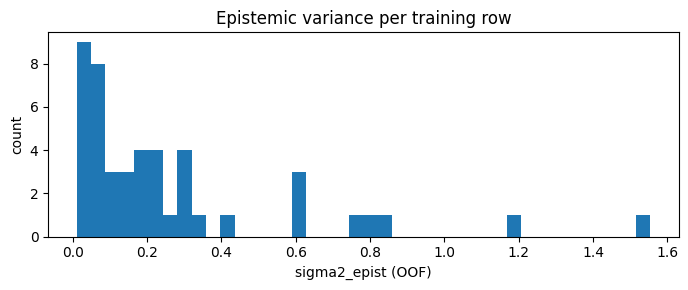

In [20]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [21]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    46.000000
mean      0.607983
std       0.654919
min       0.001328
25%       0.156904
50%       0.453030
75%       0.796450
max       2.949623
Name: iacs_final, dtype: float64

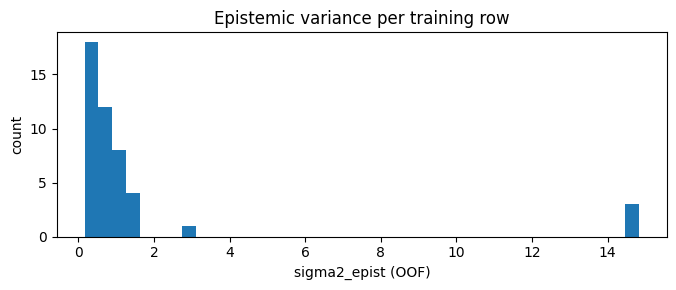

In [22]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [23]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 46
  n_truncated          = 20
  pct_truncated        = 43.47826086956522
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 2.3584939739095407
  r_tilde_sq_mean      = 0.2853313763898525
  r_tilde_sq_median    = 0.050912302582145116


In [24]:
r_tilde_sq

array([2.23423130e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.17403911e-01, 3.35021233e-01, 1.57486964e-01,
       0.00000000e+00, 1.28478541e-01, 0.00000000e+00, 1.44476449e-01,
       1.16467597e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 6.01581593e-01, 1.91101534e+00, 8.89607824e-01,
       5.86895628e-01, 5.52446613e-02, 3.06879668e-01, 0.00000000e+00,
       7.94974073e-01, 1.02019138e+00, 1.36227147e-01, 2.61669909e-01,
       0.00000000e+00, 1.17656259e-01, 3.02996411e-01, 0.00000000e+00,
       1.11517371e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.76968393e-01, 4.65799438e-02, 2.35849397e+00, 7.02770932e-01,
       0.00000000e+00, 1.57663677e-01, 1.38956104e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [25]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.70 GB / 31.57 GB (30.7%)
Disk Space Avail:   699.77 GB / 932.08 GB (75.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_annealing_iacs_240826_all-data\model_b"
Train Data Rows:    46
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (0.8580236926860781, -13.8155105579

In [26]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-5.061444,root_mean_squared_error,0.082735,15.591916,0.001000,0.008765,2,True,10
1,NeuralNetFastAI_BAG_L1,-5.250746,root_mean_squared_error,0.046590,7.596061,0.046590,7.596061,1,True,6
2,NeuralNetTorch_BAG_L1,-5.269370,root_mean_squared_error,0.035144,7.987089,0.035144,7.987089,1,True,8
3,CatBoost_BAG_L1,-5.813180,root_mean_squared_error,0.010796,4.478346,0.010796,4.478346,1,True,4
4,LightGBMLarge_BAG_L1,-5.818230,root_mean_squared_error,0.010394,1.414573,0.010394,1.414573,1,True,9
5,XGBoost_BAG_L1,-5.930981,root_mean_squared_error,0.010040,1.067576,0.010040,1.067576,1,True,7
6,LightGBM_BAG_L1,-6.300423,root_mean_squared_error,0.000987,1.296205,0.000987,1.296205,1,True,2
7,LightGBMXT_BAG_L1,-6.300423,root_mean_squared_error,0.005147,1.531562,0.005147,1.531562,1,True,1
8,ExtraTreesMSE_BAG_L1,-6.689993,root_mean_squared_error,0.031071,0.360423,0.031071,0.360423,1,True,5
9,RandomForestMSE_BAG_L1,-6.916119,root_mean_squared_error,0.048608,0.789912,0.048608,0.789912,1,True,3


In [27]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
0,0.334616,-10.743628,0.109734,88.260,88.350000
1,0.012030,-11.802487,0.109186,88.260,88.655000
2,0.253796,-9.806784,0.307340,88.260,88.800000
3,0.112057,-6.299349,0.346380,99.825,102.340000
4,0.152066,-6.689473,0.134727,99.390,102.230000
5,0.696180,-3.083013,0.067263,99.390,101.346667
6,0.596355,-4.773902,0.020618,99.230,101.355000
7,0.423252,-4.859290,0.021655,98.720,101.480000
8,0.432740,-6.781240,0.283349,97.710,100.290000
9,0.547133,-7.456553,0.170876,97.710,100.420000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [28]:
df[TARGET].var()

np.float64(13.669947372117392)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [29]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.500000,0.000000
1,0.80,0.760870,-0.039130
2,0.90,0.891304,-0.008696
3,0.95,0.891304,-0.058696


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [30]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.0902

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.500000,0.000000
1,0.80,0.782609,-0.017391
2,0.90,0.891304,-0.008696
3,0.95,0.934783,-0.015217


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [31]:
c_opt
weights

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.00084046e-06, 0.00000000e+00,
       1.30434244e-01, 0.00000000e+00, 8.01036042e-08, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 5.21739440e-01, 0.00000000e+00, 0.00000000e+00,
       4.34763483e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.58394559e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.21563352e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 8.88345027e-08, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.04346957e-01, 0.00000000e+00,
      

In [32]:
len(base_model_names)
len(weights)

106

In [33]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 0.7612, 'mae': 0.5336, 'mape': 0.5266, 'r2': 0.7372}
coverage: {0.5: 0.444, 0.8: 0.778, 0.9: 0.778, 0.95: 0.889}


In [34]:
1

1

In [35]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {
        "initial_diameter": 2.2,
        "purity": 99.7036,
        "IRI": 0.525991,
        "iacs": 94.84,
        "temperature": 723.0,
        "time": 60.0,
    },
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

Predicted iacs_final: 101.295


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [36]:
df.head(5)

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
0,1.900000,1.300000,99.9,88.260,623,30.0,88.350
1,1.900000,1.300000,99.9,88.260,623,60.0,88.655
2,1.900000,1.300000,99.9,88.260,623,90.0,88.800
3,2.160000,0.195105,99.9,99.825,573,30.0,102.340
4,2.182333,0.195105,99.9,99.390,573,30.0,102.230


In [37]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,88.613589,0.252973,0.136699,0.463117,0.680527,88.613586,1.032129,88.613589,0.680527,0.000000e+00
1,88.594786,0.202611,0.136699,0.403263,0.635030,88.594788,1.000000,88.594786,0.635030,0.000000e+00
2,88.650434,0.218466,0.136699,0.422107,0.649697,88.650436,1.013876,88.650434,0.649697,0.000000e+00
3,102.152242,0.068944,0.136699,0.244403,0.494371,102.152245,1.000000,102.152242,0.494371,4.196585e-09
4,101.912041,0.010835,0.136699,0.175342,0.418739,101.912041,1.000000,101.912041,0.418739,8.248957e-14


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [38]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\model_annealing_iacs_240826_all-data\artifacts.pkl


In [39]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "ANNEALING_SCHEMA_DATE": ANNEALING_SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\model_annealing_iacs_240826_all-data\global_config.txt


In [40]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
# h2o_oof_preds = (
#     aml_h2o.leader.cross_validation_holdout_predictions()
#     .as_data_frame()
#     .iloc[:, 0]
#     .to_numpy()
# )

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
# metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        # {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
# leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
# leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae     mape        r2
0  AutoGluon (Model A, leader)  0.643173  0.500369  0.49363  0.969066
Saved to: ../../models/annealing_iacs\model_annealing_iacs_240826_all-data


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [41]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['initial_diameter', 'IRI', 'purity', 'iacs', 'temperature', 'time']


In [42]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,88.613589,0.252973,0.136699,0.463117,0.680527,88.613586,1.032129,88.613589,0.680527,0.000000e+00
1,88.594786,0.202611,0.136699,0.403263,0.635030,88.594788,1.000000,88.594786,0.635030,0.000000e+00
2,88.650434,0.218466,0.136699,0.422107,0.649697,88.650436,1.013876,88.650434,0.649697,0.000000e+00
3,102.152242,0.068944,0.136699,0.244403,0.494371,102.152245,1.000000,102.152242,0.494371,4.196585e-09
4,101.912041,0.010835,0.136699,0.175342,0.418739,101.912041,1.000000,101.912041,0.418739,8.248957e-14


In [44]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {
        "initial_diameter": 2.2,
        "purity": 99.7036,
        "IRI": 0.525991,
        "iacs": 94.84,
        "temperature": 723.0,
        "time": 60.0,
    },
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 101.295


In [45]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.


# 12 Adhoc running

In [94]:
IACS_TAG_DIR = EXPERIMENT_DIR
UTS_TAG_DIR = os.path.join(
    varv.PATHS.models, "annealing_uts", "experiments", "annealing-uts-v1-best_quality"
)
ELONGATION_TAG_DIR = os.path.join(
    varv.PATHS.models, "annealing_elongation", "experiments", "annealing-schema230726"
)

In [63]:
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {
        "initial_diameter": 2.2,
        "purity": 99.7036,
        "IRI": 0.525991,
        "iacs": 94.84,
        "temperature": 750.0 + 273,
        "time": 90.0,
    },
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 101.843


In [97]:
from src.modeling.MBCInference import MBCInference

mbc = MBCInference(modl, load)

MATERIAL_PROPERTIES = {
    "initial_diameter": 2.2,
    "purity": 99.7036,
    "IRI": 0.525991,
    "iacs": 94.84,
    "tensile_strength": 362.31,
    "elongation": 6.65,
}

# ---- Grid (inclusive of upper bound, like the deterministic build_param_grid) ----
OPERATIONAL_LIMITS = {
    "temperature": [200+273, 600 + 273],  # Kelvin
    "time": [30, 120],  # minutes
}
STEP = {"temperature": 10, "time": 5}

In [98]:
down_bundles = mbc.load_surrogates_best(
    {
        "iacs": IACS_TAG_DIR,
        "uts": UTS_TAG_DIR,
        "elongation": ELONGATION_TAG_DIR
    },
     metric="rmse",
)

In [99]:
param_grid = mbc.build_param_grid(OPERATIONAL_LIMITS, STEP)
df_grid = mbc.build_state_grid_df(MATERIAL_PROPERTIES, param_grid)

print(f"Grid: {len(param_grid['temperature'])} temperatures x "
      f"{len(param_grid['time'])} times = {len(df_grid)} cells")
df_grid.head()

Grid: 41 temperatures x 19 times = 779 cells


,initial_diameter,purity,IRI,iacs,tensile_strength,elongation,temperature,time
0,2.2,99.7036,0.525991,94.84,362.31,6.65,473,30
1,2.2,99.7036,0.525991,94.84,362.31,6.65,473,35
2,2.2,99.7036,0.525991,94.84,362.31,6.65,473,40
3,2.2,99.7036,0.525991,94.84,362.31,6.65,473,45
4,2.2,99.7036,0.525991,94.84,362.31,6.65,473,50


In [100]:
df_pred = mbc.predict_all(down_bundles, df_grid, ood_gamma=1.0)


In [101]:
df_pred

,initial_diameter,purity,IRI,iacs,tensile_strength,elongation,temperature,time,iacs_mu,iacs_sigma,...,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
0,2.2,99.7036,0.525991,94.84,362.31,6.65,473,30,98.530505,1.073896,...,364.319336,1.0,272.465054,16.683703,0.0,49.469179,7.715772,11.769248,1.821305,2.117084
1,2.2,99.7036,0.525991,94.84,362.31,6.65,473,35,98.691385,1.079140,...,364.319336,1.0,272.386453,16.696525,0.0,49.473471,7.744768,11.871587,1.821305,2.120265
2,2.2,99.7036,0.525991,94.84,362.31,6.65,473,40,98.854049,1.085377,...,364.319336,1.0,272.375846,16.696829,0.0,49.480145,7.792236,12.039951,1.821305,2.125913
3,2.2,99.7036,0.525991,94.84,362.31,6.65,473,45,99.010763,1.122532,...,364.319336,1.0,272.366555,16.697043,0.0,49.488364,7.854624,12.262798,1.821305,2.134009
4,2.2,99.7036,0.525991,94.84,362.31,6.65,473,50,99.173193,1.166079,...,364.319336,1.0,275.178311,17.438703,0.0,48.910458,10.269922,22.256264,1.821305,2.144524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,2.2,99.7036,0.525991,94.84,362.31,6.65,873,100,101.857434,1.775083,...,364.319336,1.0,212.811658,21.094022,0.0,54.447611,4.548700,2.902076,1.821305,2.115799
775,2.2,99.7036,0.525991,94.84,362.31,6.65,873,105,101.901840,1.883413,...,364.319336,1.0,212.807654,21.106613,0.0,54.449747,4.572002,2.950594,1.821305,2.139481
776,2.2,99.7036,0.525991,94.84,362.31,6.65,873,110,101.944772,1.997385,...,364.319336,1.0,213.656125,21.149596,0.0,54.452864,4.594316,2.997286,1.821305,2.165330
777,2.2,99.7036,0.525991,94.84,362.31,6.65,873,115,101.980928,2.107169,...,364.319336,1.0,213.652428,21.162040,0.0,54.457409,4.613625,3.037875,1.821305,2.193270


In [102]:
df_pred.to_csv(os.path.join(varv.PATHS.data_enriched, "annealing_predictions_all_MBC_LT-12.csv"))

In [89]:
df_pred.sort_values(by="iacs_mu", ascending=False).head(15)

,initial_diameter,purity,IRI,iacs,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,iacs_ood_multiplier,iacs_mu_trunc,iacs_sigma_trunc,iacs_p_above_max
759,2.2,99.7036,0.525991,94.84,863,120,102.087531,2.147240,3.742748,0.136699,1.308489,101.713374,1.838729,0.087489
740,2.2,99.7036,0.525991,94.84,853,120,102.085611,2.096971,3.563230,0.136699,1.284098,101.738584,1.807066,0.082293
721,2.2,99.7036,0.525991,94.84,843,120,102.084273,2.040383,3.366234,0.136699,1.260161,101.766765,1.771040,0.076501
702,2.2,99.7036,0.525991,94.84,833,120,102.076627,1.987138,3.185799,0.136699,1.236706,101.787572,1.737857,0.070626
683,2.2,99.7036,0.525991,94.84,823,120,102.069005,1.936170,3.017549,0.136699,1.213759,101.806317,1.705818,0.065037
664,2.2,99.7036,0.525991,94.84,813,120,102.060512,1.886147,2.856665,0.136699,1.191350,101.822967,1.674174,0.059562
758,2.2,99.7036,0.525991,94.84,863,115,102.053349,2.034846,3.347251,0.136699,1.268405,101.746177,1.772320,0.073795
645,2.2,99.7036,0.525991,94.84,803,120,102.052181,1.838242,2.706546,0.136699,1.169511,101.837793,1.643532,0.054400
739,2.2,99.7036,0.525991,94.84,853,115,102.048767,1.980966,3.165190,0.136699,1.243760,101.769204,1.738106,0.068139
720,2.2,99.7036,0.525991,94.84,843,115,102.045820,1.923097,2.975096,0.136699,1.219574,101.794398,1.700688,0.062250


In [88]:
df_pred[df_pred["time"] == 60].sort_values(by="iacs_mu", ascending=False)

,initial_diameter,purity,IRI,iacs,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,iacs_ood_multiplier,iacs_mu_trunc,iacs_sigma_trunc,iacs_p_above_max
747,2.2,99.7036,0.525991,94.84,863,60,101.497994,1.112604,0.904873,0.136699,1.0,101.494859,1.107654,0.000823
728,2.2,99.7036,0.525991,94.84,853,60,101.489122,1.099837,0.881108,0.136699,1.0,101.486432,1.095532,0.000706
709,2.2,99.7036,0.525991,94.84,843,60,101.481053,1.082073,0.848494,0.136699,1.0,101.478871,1.078516,0.000573
690,2.2,99.7036,0.525991,94.84,833,60,101.468018,1.067935,0.822919,0.136699,1.0,101.466221,1.064959,0.000471
671,2.2,99.7036,0.525991,94.84,823,60,101.454835,1.054415,0.798774,0.136699,1.0,101.453358,1.051928,0.000387
652,2.2,99.7036,0.525991,94.84,813,60,101.441365,1.041344,0.775725,0.136699,1.0,101.440156,1.039274,0.000316
766,2.2,99.7036,0.525991,94.84,873,60,101.432351,1.124101,0.926511,0.136699,1.0,101.429435,1.119461,0.000752
633,2.2,99.7036,0.525991,94.84,803,60,101.427498,1.028498,0.753353,0.136699,1.0,101.426514,1.026786,0.000257
614,2.2,99.7036,0.525991,94.84,793,60,101.414786,1.015228,0.730533,0.136699,1.0,101.413992,1.013826,0.000207
595,2.2,99.7036,0.525991,94.84,783,60,101.399886,1.002656,0.709188,0.136699,1.0,101.399251,1.001515,0.000165
